<a href="https://colab.research.google.com/github/AlvarengaCarlo5/UnB_Rede_Neural_Aplicado_-_Seguran-a/blob/main-trabalhos/IIoT_Article_Project_Oil_and_Gas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detecção de Falhas com IIoT em Instalações de Petróleo e Gás

**Base de Dados:** [IIoT for gas and oil](https://www.kaggle.com/datasets/dako123/iiot-for-gas-and-oil)

**Descrição do Projeto:**
Este notebook tem como objetivo realizar a comparação de modelos de IA para detectar falhas de equipamentos utilizando dados reais de sensores, base do kaggle apresentada acima.

In [ ]:

!pip install -q kagglehub[pandas-datasets] imbalanced-learn

In [ ]:
# 1. IMPORTAÇÃO DE BIBLIOTECAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Kaggle Hub (Para download direto da base)
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Scikit-Learn e Balanceamento (Imbalanced-Learn)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

# TensorFlow / Keras (Modelos Sequenciais)
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras import layers
from tensorflow.keras.layers import LSTM, Dense, Input, MultiHeadAttention, GlobalAveragePooling1D

In [ ]:
# 2. CARREGAMENTO E PRÉ-PROCESSAMENTO DOS DADOS
import os

print("Conection to Kaggle and download")

caminho_pasta = kagglehub.dataset_download("dako123/iiot-for-gas-and-oil")
print(f"Dataset Save in: {caminho_pasta}")

#Busca o CSV baixado
arquivos_csv = [f for f in os.listdir(caminho_pasta) if f.endswith('.csv')]

if arquivos_csv:
    caminho_arquivo = os.path.join(caminho_pasta, arquivos_csv[0])
    print(f"Carregando o arquivo: {arquivos_csv[0]}\n")

    # Lê o arquivo usando o Pandas padrão
    df = pd.read_csv(caminho_arquivo)

    print(f"Dimensões do DataFrame: {df.shape}")
    display(df.head())
else:
    print("Erro: Nenhum arquivo .csv foi encontrado")

# -------------------------------------------------------------------
# Tratamento dos dados
from sklearn.preprocessing import StandardScaler

# 1. Ordenação dos registros pela linha do tempo
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp')

# 2. Removendo colunas de "vazamento" (pós-falha) e inúteis
colunas_para_remover = [
    'record_id', 'work_order_id', 'failure_start_time', 'failure_end_time',
    'repair_start_time', 'repair_end_time', 'failure_mode', 'failure_mode_detail',
    'maintenance_action', 'maintenance_type', 'downtime_duration', 'root_cause',
    'operator_action', 'intervention', 'production_loss', 'spare_part_replaced'
]
df = df.drop(columns=colunas_para_remover, errors='ignore')

# 3. Pivotamento de sensores (De Formato Longo para Largo)
# agrupamento por tempo, equipamento e status. As colunas viram as tags dos sensores.
df_pivot = df.pivot_table(
    index=['timestamp', 'asset_id', 'equipment_id', 'operating_state', 'failure_flag'],
    columns='sensor_tag',
    values='measurement_value',
    aggfunc='mean' # Se houver 2 leituras no mesmo milissegundo, tira a média
).reset_index()

# Renomeia o eixo das colunas para remover o nome "sensor_tag", sobrando
df_pivot.columns.name = None

# 4. Tratamento de valores nulos
# Devido a assincronicidade dos sensores, temos NaNs.
# O ffill copia a última leitura daquele sensor específico para preencher o vazio.
df_pivot.ffill(inplace=True)
df_pivot.fillna(0, inplace=True)

# 5. ONE-HOT ENCODING (Para as categorias que sobraram)
colunas_categoricas = ['asset_id', 'equipment_id', 'operating_state']
cat_cols_presentes = [col for col in colunas_categoricas if col in df_pivot.columns]
df_final = pd.get_dummies(df_pivot, columns=cat_cols_presentes, drop_first=True)

# descartando o timestamp após estabelecer a ordem temporal
df_final = df_final.drop('timestamp', axis=1, errors='ignore')

# 6. Separação das variáveis (X) E ALVO (y)
X = df_final.drop('failure_flag', axis=1)
y = df_final['failure_flag']

# 7. Divisão dos conjuntos de treino e teste (80/20)
print("Divisão em treino e teste")
tamanho_treino = int(len(X) * 0.8)
X_train, X_test = X.iloc[:tamanho_treino], X.iloc[tamanho_treino:]
y_train, y_test = y.iloc[:tamanho_treino], y.iloc[tamanho_treino:]

# 8. Normalização dos dados
print("Normalização dos dados")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 9. Balanceamento da tabela (SMOTE para Random Forest)
print("Aplicando SMOTE...")
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

# 10. Definindo janelas temporais (Para Redes Neurais LSTM/Transformer)
def criar_janelas_temporais(X, y, time_steps=10):
    Xs, ys = [], []
    # y deve ser resetado o index para garantir alinhamento no loop
    y_reset = y.reset_index(drop=True)
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y_reset.iloc[i + time_steps])
    return np.array(Xs), np.array(ys)

TIME_STEPS = 10
X_tr_seq, y_tr_seq = criar_janelas_temporais(X_train_scaled, y_train, TIME_STEPS)
X_te_seq, y_te_seq = criar_janelas_temporais(X_test_scaled, y_test, TIME_STEPS)

print("concluído")
print(f"Colunas Preditivas: {list(X.columns)}")

Conection to Kaggle and download
Using Colab cache for faster access to the 'iiot-for-gas-and-oil' dataset.
Dataset Save in: /kaggle/input/iiot-for-gas-and-oil
Carregando o arquivo: oilgas_predictive_maintenance_10000.csv

Dimensões do DataFrame: (10000, 30)


,record_id,timestamp,asset_id,equipment_id,well_id,component_id,sensor_tag,measurement_value,unit,operating_state,...,downtime_duration,root_cause,operator_action,intervention,production_loss,spare_part_replaced,location,field,pad,Temp_p
0,1,2025-01-01 03:00:00,AST-1016,EQ-COM-017,WELL-SA-017,bearing_assembly,bearing_temp,49.50,degC,run,...,NaN,NaN,alarm_acknowledged,production engineer review,NaN,NaN,Booster Area,Sarybulak,PAD-F,53.6
1,2,2025-01-01 08:00:00,AST-1002,EQ-SUR-003,WELL-KA-003,motor,current_draw,22.40,A,run,...,NaN,NaN,field_reset,maintenance crew mobilized,NaN,NaN,Remote Pad West,Karatau,PAD-B,68.4
2,3,2025-01-01 09:00:00,AST-1016,EQ-COM-017,WELL-SA-017,bearing_assembly,vibration_axial,3.23,mm/s,run,...,NaN,NaN,manual_restart,operator dispatched,NaN,NaN,Booster Area,Sarybulak,PAD-F,51.0
3,4,2025-01-01 10:00:00,AST-1042,EQ-ESP-043,WELL-SA-043,motor,motor_temp,55.60,degC,run,...,NaN,NaN,NaN,production engineer review,NaN,NaN,Booster Area,Sarybulak,PAD-E,60.0
4,5,2025-01-01 12:00:00,AST-1014,EQ-ESP-015,WELL-NO-015,pump_stage,discharge_pressure,100.90,bar,run,...,NaN,NaN,field_reset,NaN,NaN,NaN,Booster Area,North Delta,PAD-F,69.9


Divisão em treino e teste
Normalização dos dados
Aplicando SMOTE...
concluído
Colunas Preditivas: ['bearing_temp', 'casing_pressure', 'current_draw', 'discharge_pressure', 'flow_rate', 'intake_pressure', 'motor_temp', 'vibration_axial', 'vibration_radial', 'voltage', 'asset_id_AST-1001', 'asset_id_AST-1002', 'asset_id_AST-1003', 'asset_id_AST-1004', 'asset_id_AST-1005', 'asset_id_AST-1006', 'asset_id_AST-1007', 'asset_id_AST-1008', 'asset_id_AST-1009', 'asset_id_AST-1010', 'asset_id_AST-1011', 'asset_id_AST-1012', 'asset_id_AST-1013', 'asset_id_AST-1014', 'asset_id_AST-1015', 'asset_id_AST-1016', 'asset_id_AST-1017', 'asset_id_AST-1018', 'asset_id_AST-1019', 'asset_id_AST-1020', 'asset_id_AST-1021', 'asset_id_AST-1022', 'asset_id_AST-1023', 'asset_id_AST-1024', 'asset_id_AST-1025', 'asset_id_AST-1026', 'asset_id_AST-1027', 'asset_id_AST-1028', 'asset_id_AST-1029', 'asset_id_AST-1030', 'asset_id_AST-1031', 'asset_id_AST-1032', 'asset_id_AST-1033', 'asset_id_AST-1034', 'asset_id_AST-1035

A base original tratava diferentes leituras de sensores em uma única coluna genérica. Utilizei a técnica de pivotamento (pivot_table) atrelada ao Forward Fill para reconstruir o estado holístico do equipamento a cada instante de tempo, permitindo que as Redes Neurais correlacionassem padrões multivariados (ex: aumento de vibração simultâneo à queda de pressão).

Iniciando treinamento do Random Forest...
Treinamento concluído!

--------------------------------------------------
RELATÓRIO DE CLASSIFICAÇÃO (Métricas textuais):
              precision    recall  f1-score   support

           0     0.9717    0.9579    0.9648      1829
           1     0.4500    0.5526    0.4961       114

    accuracy                         0.9341      1943
   macro avg     0.7109    0.7553    0.7304      1943
weighted avg     0.9411    0.9341    0.9373      1943

--------------------------------------------------


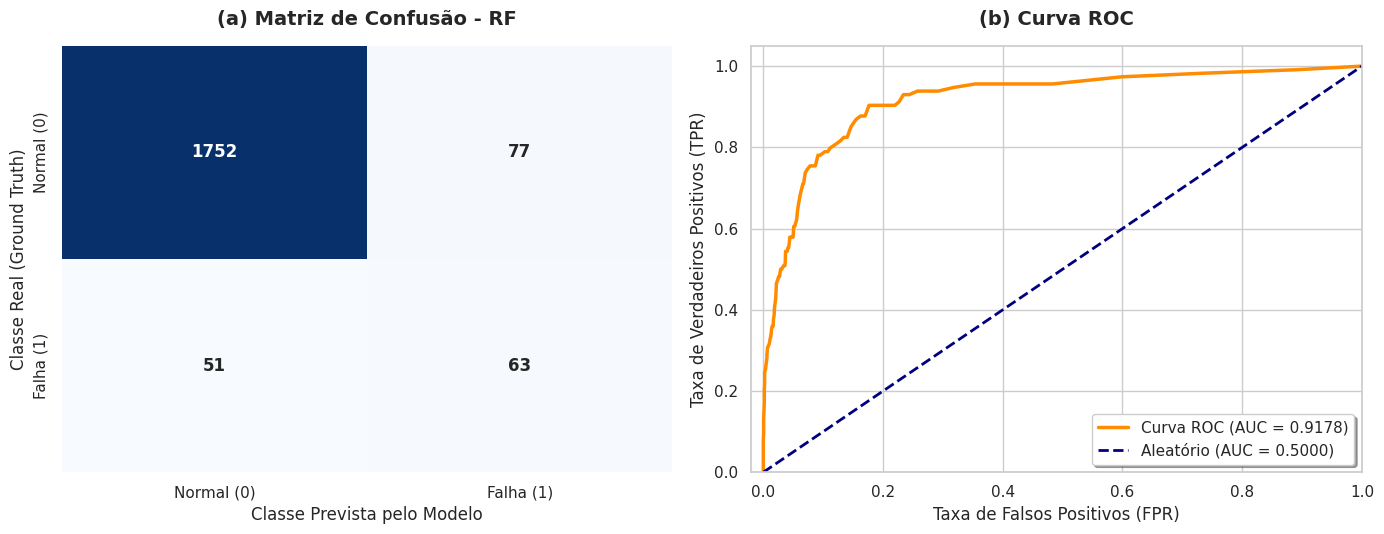

In [ ]:
# 3.1. Aplicação de RF (Random Forest)
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

print("Iniciando treinamento do Random Forest...")

# 1. Instanciação e Treinamento
# Devio ao desbalancemaneto do dataset, utilizo class_weight='balanced' para dar mais peso à classe minoritária (falhas)
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)

# 2. Predições
# Usando X_test_scaled gerado na etapa de pré-processamento
y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1] # Pega a probabilidade de ser Falha (Classe 1)

print("Treinamento concluído!\n")
print("-" * 50)
print("RELATÓRIO DE CLASSIFICAÇÃO (Métricas textuais):")
print(classification_report(y_test, y_pred_rf, digits=4))
print("-" * 50)

# 3. Gerando gráficos
sns.set_theme(style="whitegrid") # Fundo limpo, preferido em artigos
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- Matriz de Confusão ---
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            annot_kws={"size": 12, "weight": "bold"},
            xticklabels=['Normal (0)', 'Falha (1)'],
            yticklabels=['Normal (0)', 'Falha (1)'])

axes[0].set_title('(a) Matriz de Confusão - RF', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Classe Prevista pelo Modelo', fontsize=12)
axes[0].set_ylabel('Classe Real (Ground Truth)', fontsize=12)

# --- Curva ROC e AUC ---
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2.5, label=f'Curva ROC (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aleatório (AUC = 0.5000)')
axes[1].set_xlim([-0.02, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
axes[1].set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
axes[1].set_title('(b) Curva ROC', fontsize=14, fontweight='bold', pad=15)
axes[1].legend(loc="lower right", fontsize=11, frameon=True, shadow=True)

# Ajuste de layout
plt.tight_layout()
plt.show()

Iniciando treinamento do modelo LSTM...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


243/243 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.5219 - loss: 0.7067
Epoch 2/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5801 - loss: 0.6677
Epoch 3/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6297 - loss: 0.6363
Epoch 4/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6921 - loss: 0.5842
Epoch 5/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7669 - loss: 0.4846
Epoch 6/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8357 - loss: 0.3616
Epoch 7/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8739 - loss: 0.2805
Epoch 8/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9259 - loss: 0.1834
Epoch 9/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9456 - loss: 0.1336
Epoch 10/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9718 - loss: 0.0752
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

Treinamento LSTM concluído!
--------------------------------------------------
RELATÓRIO DE CLASSIFICAÇÃO (M

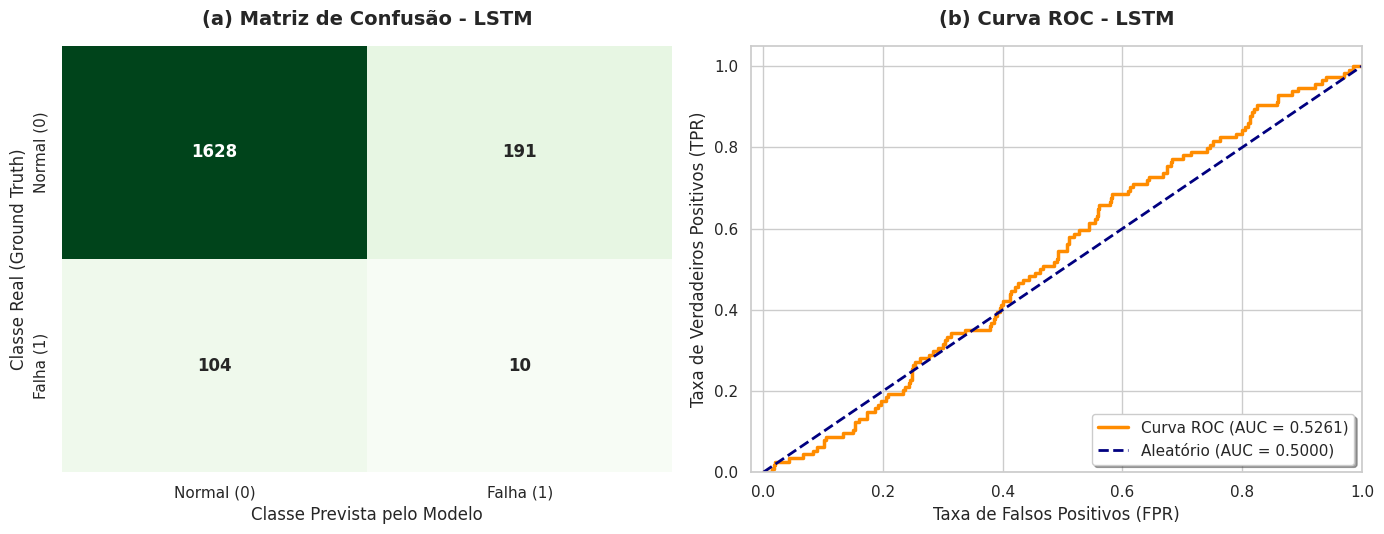

In [ ]:
# 3.2. Rede LSTM
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

print("Iniciando treinamento do modelo LSTM...")

# Cálculo de Pesos para Desbalanceamento
# Redes recorrentes precisam da ordem cronológica, impossibilitando o tratamento de smote
# Defino pra rede que a classe 1 (falha) é rara e erros nela são mais graves
pesos = compute_class_weight('balanced', classes=np.unique(y_tr_seq), y=y_tr_seq)
class_weights = dict(enumerate(pesos))

# input_shape = (TIME_STEPS, NUM_FEATURES) -> Dinâmico baseado no X_tr_seq
lstm = Sequential([
    LSTM(64, activation='relu', input_shape=(10, X_tr_seq.shape[2])),
    Dense(1, activation='sigmoid')
])

lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Treinamento da rede
historico_lstm = lstm.fit(
    X_tr_seq, y_tr_seq,  # cenario real, gabarito
    epochs=10,       # epochs = 10 - para 10 revisões da base
    batch_size=32,   # pegando blocos de 32
    class_weight=class_weights, # Reforça a raridade de falhas e seu peso
    verbose=1
)

# 4. Predições de probabilidade para curba ROC
y_prob_lstm = lstm.predict(X_te_seq).ravel() # .ravel() converte 2D para 1D
y_pred_lstm = (y_prob_lstm > 0.5).astype(int)

print("\nTreinamento LSTM concluído!")
print("-" * 50)
print("RELATÓRIO DE CLASSIFICAÇÃO (Métricas textuais):")
print(classification_report(y_te_seq, y_pred_lstm, digits=4))
print("-" * 50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- Matriz de Confusão ---
cm_lstm = confusion_matrix(y_te_seq, y_pred_lstm)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Greens', ax=axes[0], cbar=False,
            annot_kws={"size": 12, "weight": "bold"},
            xticklabels=['Normal (0)', 'Falha (1)'],
            yticklabels=['Normal (0)', 'Falha (1)'])

axes[0].set_title('(a) Matriz de Confusão - LSTM', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Classe Prevista pelo Modelo', fontsize=12)
axes[0].set_ylabel('Classe Real (Ground Truth)', fontsize=12)

# --- Curva ROC e AUC ---
fpr_lstm, tpr_lstm, _ = roc_curve(y_te_seq, y_prob_lstm)
roc_auc_lstm = auc(fpr_lstm, tpr_lstm)

axes[1].plot(fpr_lstm, tpr_lstm, color='darkorange', lw=2.5, label=f'Curva ROC (AUC = {roc_auc_lstm:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aleatório (AUC = 0.5000)')
axes[1].set_xlim([-0.02, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
axes[1].set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
axes[1].set_title('(b) Curva ROC - LSTM', fontsize=14, fontweight='bold', pad=15)
axes[1].legend(loc="lower right", fontsize=11, frameon=True, shadow=True)

plt.tight_layout()

plt.show()

Iniciando treinamento do modelo Transformer...
Epoch 1/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5701 - loss: 0.6944
Epoch 2/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4767 - loss: 0.6835
Epoch 3/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5907 - loss: 0.6797
Epoch 4/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5822 - loss: 0.6717
Epoch 5/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5841 - loss: 0.6650
Epoch 6/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5989 - loss: 0.6565
Epoch 7/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6223 - loss: 0.6461
Epoch 8/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6264 - loss: 0.6361
Epoch 9/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6377 - loss: 0.6257
Epoch 10/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6511 - loss: 0.6154
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Treinamento Transformer concluído!
----------------

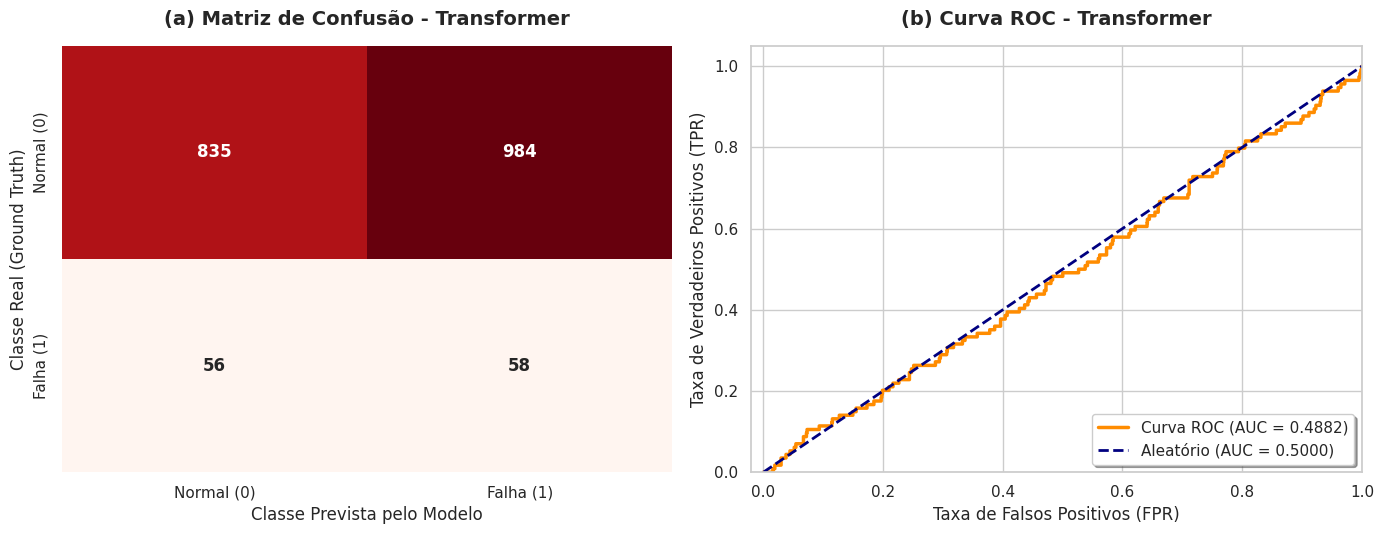

In [ ]:
# 3.3. Treinamento e Avaliação de TRANSFORMER
print("Iniciando treinamento do modelo Transformer...")

# Ajuste do input_shape para ler dinamicamente o número exato de colunas do X_tr_seq
inputs = layers.Input(shape=(10, X_tr_seq.shape[2]))

# Camada de Atenção
x = layers.MultiHeadAttention(num_heads=2, key_dim=2)(inputs, inputs)
x = layers.GlobalAveragePooling1D()(x)

# Camada de Saída
outputs = layers.Dense(1, activation='sigmoid')(x)

trans = Model(inputs, outputs)
trans.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Aplicando as mesmas 10 epochs, lotes de 32 e o essencial 'class_weights' calculado no bloco do LSTM
historico_trans = trans.fit(
    X_tr_seq, y_tr_seq,
    epochs=10,
    batch_size=32,
    class_weight=class_weights,
    verbose=1
)

# Predições - extraindo probabilidade para curva ROC
y_prob_trans = trans.predict(X_te_seq).ravel()
y_pred_trans = (y_prob_trans > 0.5).astype(int)

print("\nTreinamento Transformer concluído!")
print("-" * 50)
print("RELATÓRIO DE CLASSIFICAÇÃO (Métricas textuais):")
print(classification_report(y_te_seq, y_pred_trans, digits=4))
print("-" * 50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- Matriz de Confusão ---
cm_trans = confusion_matrix(y_te_seq, y_pred_trans)
sns.heatmap(cm_trans, annot=True, fmt='d', cmap='Reds', ax=axes[0], cbar=False,
            annot_kws={"size": 12, "weight": "bold"},
            xticklabels=['Normal (0)', 'Falha (1)'],
            yticklabels=['Normal (0)', 'Falha (1)'])

axes[0].set_title('(a) Matriz de Confusão - Transformer', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Classe Prevista pelo Modelo', fontsize=12)
axes[0].set_ylabel('Classe Real (Ground Truth)', fontsize=12)

# --- Curva ROC e AUC ---
fpr_trans, tpr_trans, _ = roc_curve(y_te_seq, y_prob_trans)
roc_auc_trans = auc(fpr_trans, tpr_trans)

axes[1].plot(fpr_trans, tpr_trans, color='darkorange', lw=2.5, label=f'Curva ROC (AUC = {roc_auc_trans:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aleatório (AUC = 0.5000)')
axes[1].set_xlim([-0.02, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
axes[1].set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
axes[1].set_title('(b) Curva ROC - Transformer', fontsize=14, fontweight='bold', pad=15)
axes[1].legend(loc="lower right", fontsize=11, frameon=True, shadow=True)

plt.tight_layout()

plt.show()